Using device: cuda


C:\Users\arman\AppData\Local\Temp\ipykernel_30320\3158695220.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality_grade', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[0], palette='viridis')
C:\Users\arman\AppData\Local\Temp\ipykernel_30320\3158695220.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_grade', y='thread_count', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[1], palette='viridis')


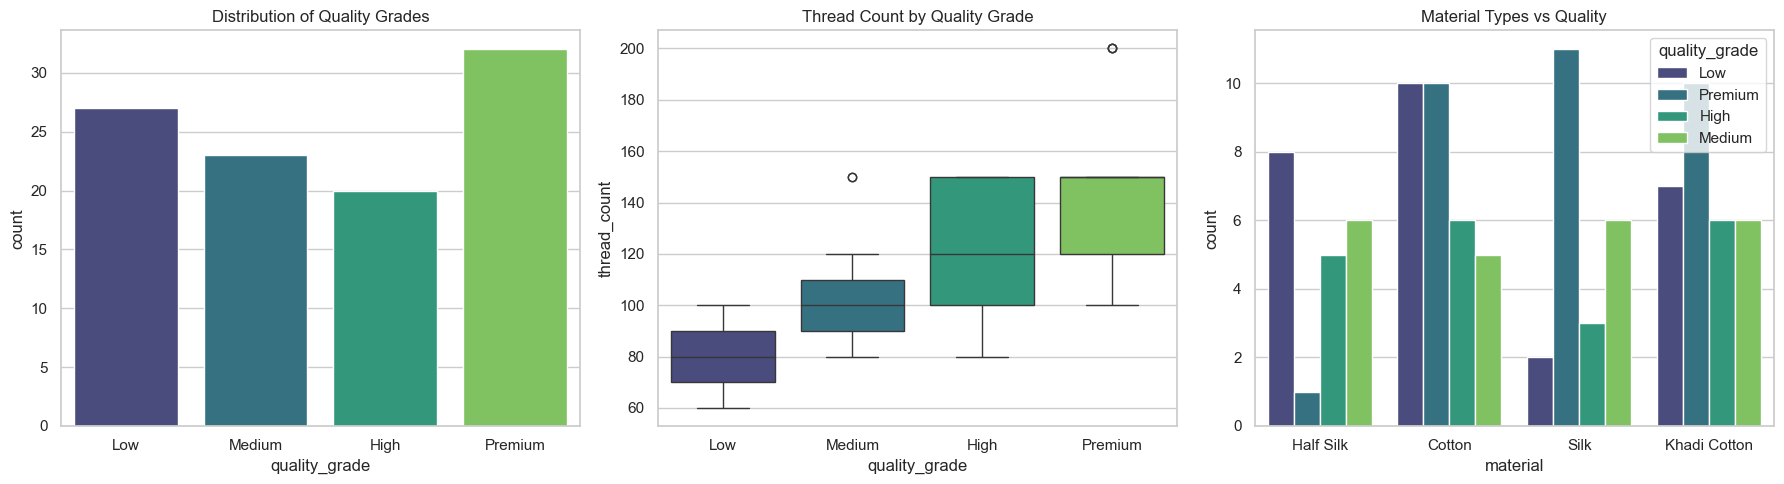


--- Visualizing Multimodal Data Mapping ---


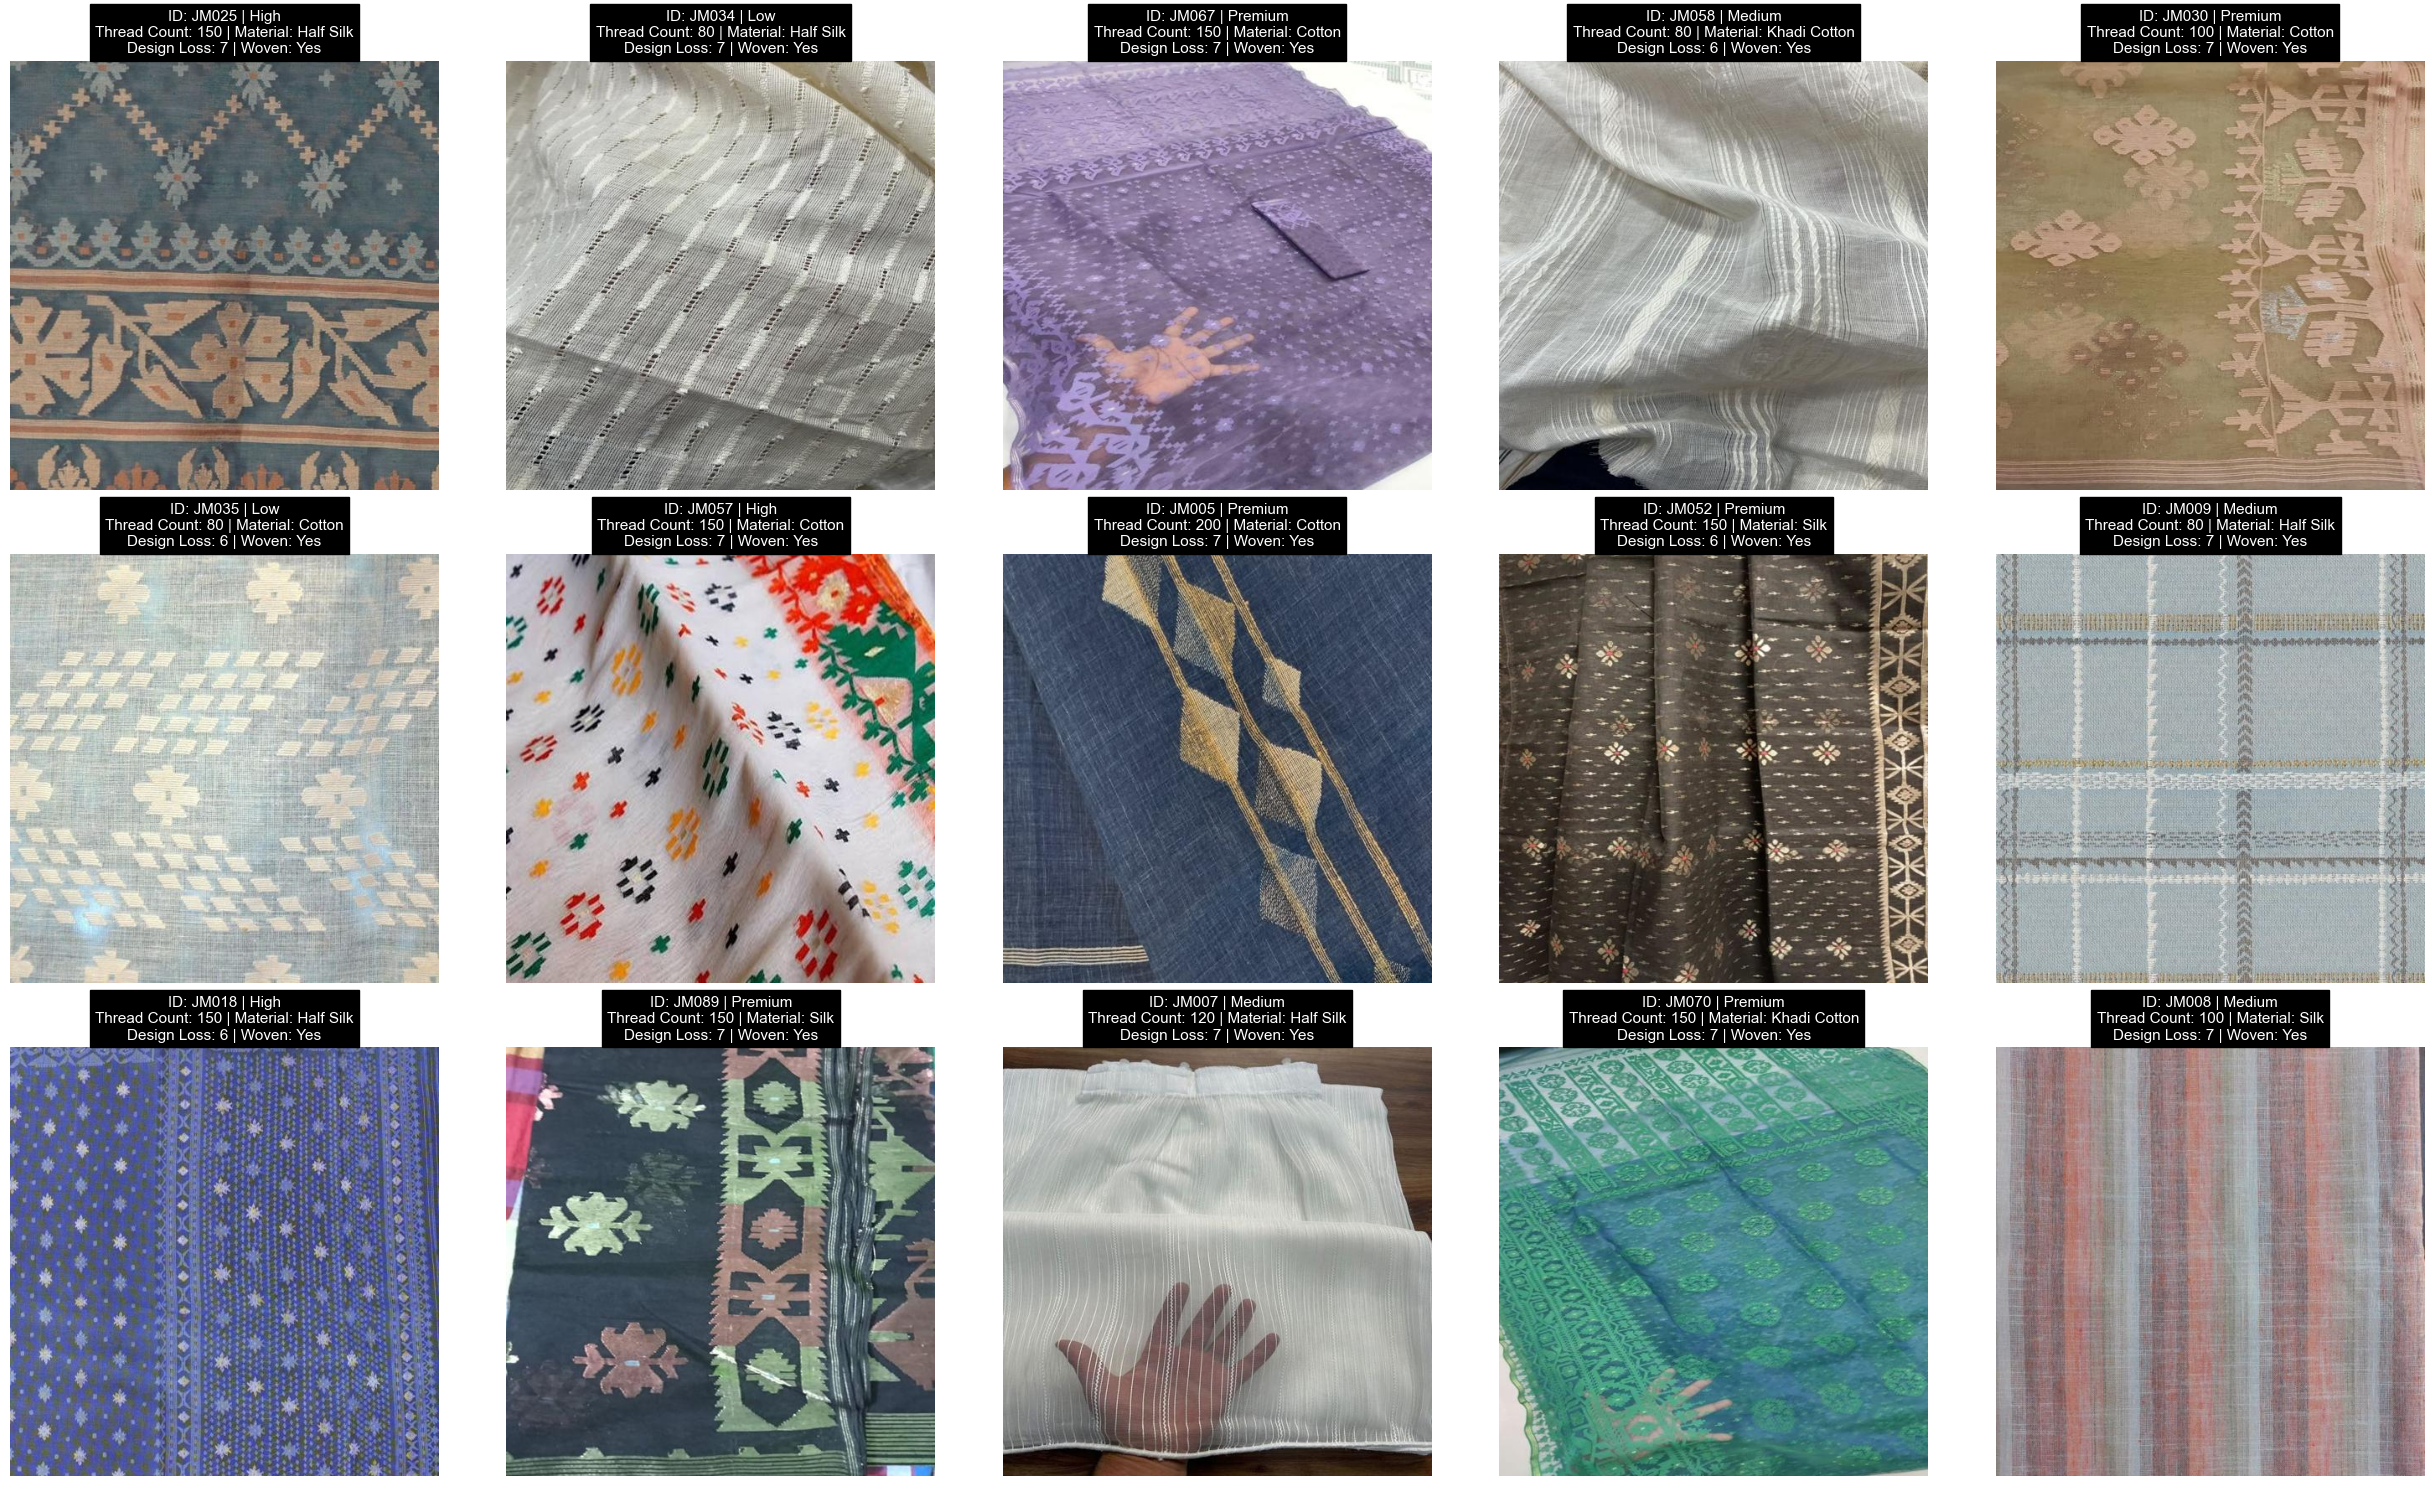

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load the Tabular Data
excel_filename = 'Jamdani_Samples.xlsx' # Ensure this matches your uploaded file name
df = pd.read_excel(excel_filename)

# 2. Exploratory Data Visualization (Charts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



sns.countplot(data=df, x='quality_grade', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Quality Grades')

sns.boxplot(data=df, x='quality_grade', y='thread_count', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[1], palette='viridis')
axes[1].set_title('Thread Count by Quality Grade')

sns.countplot(data=df, x='material', hue='quality_grade', ax=axes[2], palette='viridis')
axes[2].set_title('Material Types vs Quality')

plt.tight_layout()
plt.show()


import math

# 3. Visualize Sample Images with their Mapped Features
print("\n--- Visualizing Multimodal Data Mapping ---")
image_folder = './Images' # Ensure your images are inside this folder

# Sample 15 random rows to visualize in a matrix
num_samples = 15
sample_df = df.sample(n=num_samples)

# Define the matrix layout (e.g., 5 columns)
cols = 5
rows = math.ceil(num_samples / cols)

# Adjust figsize so the matrix is wide and tall enough to read the text
# Width=25, Height=15 provides a good balance for a 5-column grid
plt.figure(figsize=(25, 15))

for i, (index, row) in enumerate(sample_df.iterrows()):
    img_name = row['image_name']
    img_path = os.path.join(image_folder, img_name)

    # Subplot takes (rows, columns, current_index)
    plt.subplot(rows, cols, i + 1)

    # Check if the image actually exists in the folder before trying to draw it
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)

        # Map the tabular features to the image title
        feature_text = (
            f"ID: {row['image_id']} | {row['quality_grade']}\n"
            f"Thread Count: {row['thread_count']} | Material: {row['material']}\n"
            f"Design Loss: {row['design_loss']} | Woven: {row['handwoven']}"
        )

        # Font size increased slightly to remain readable in the larger grid
        plt.title(feature_text, fontsize=11, loc='center', backgroundcolor='black', color='white')
        plt.axis('off')
    else:
        # Fallback if the image is missing from the folder
        plt.text(0.5, 0.5, f"Image Not Found:\n{img_name}",
                 ha='center', va='center', fontsize=12, color='red')
        plt.axis('off')

# tight_layout ensures the titles and images don't overlap in the matrix
plt.tight_layout()
plt.show()

--- Advanced Statistical Visualizations for Report ---


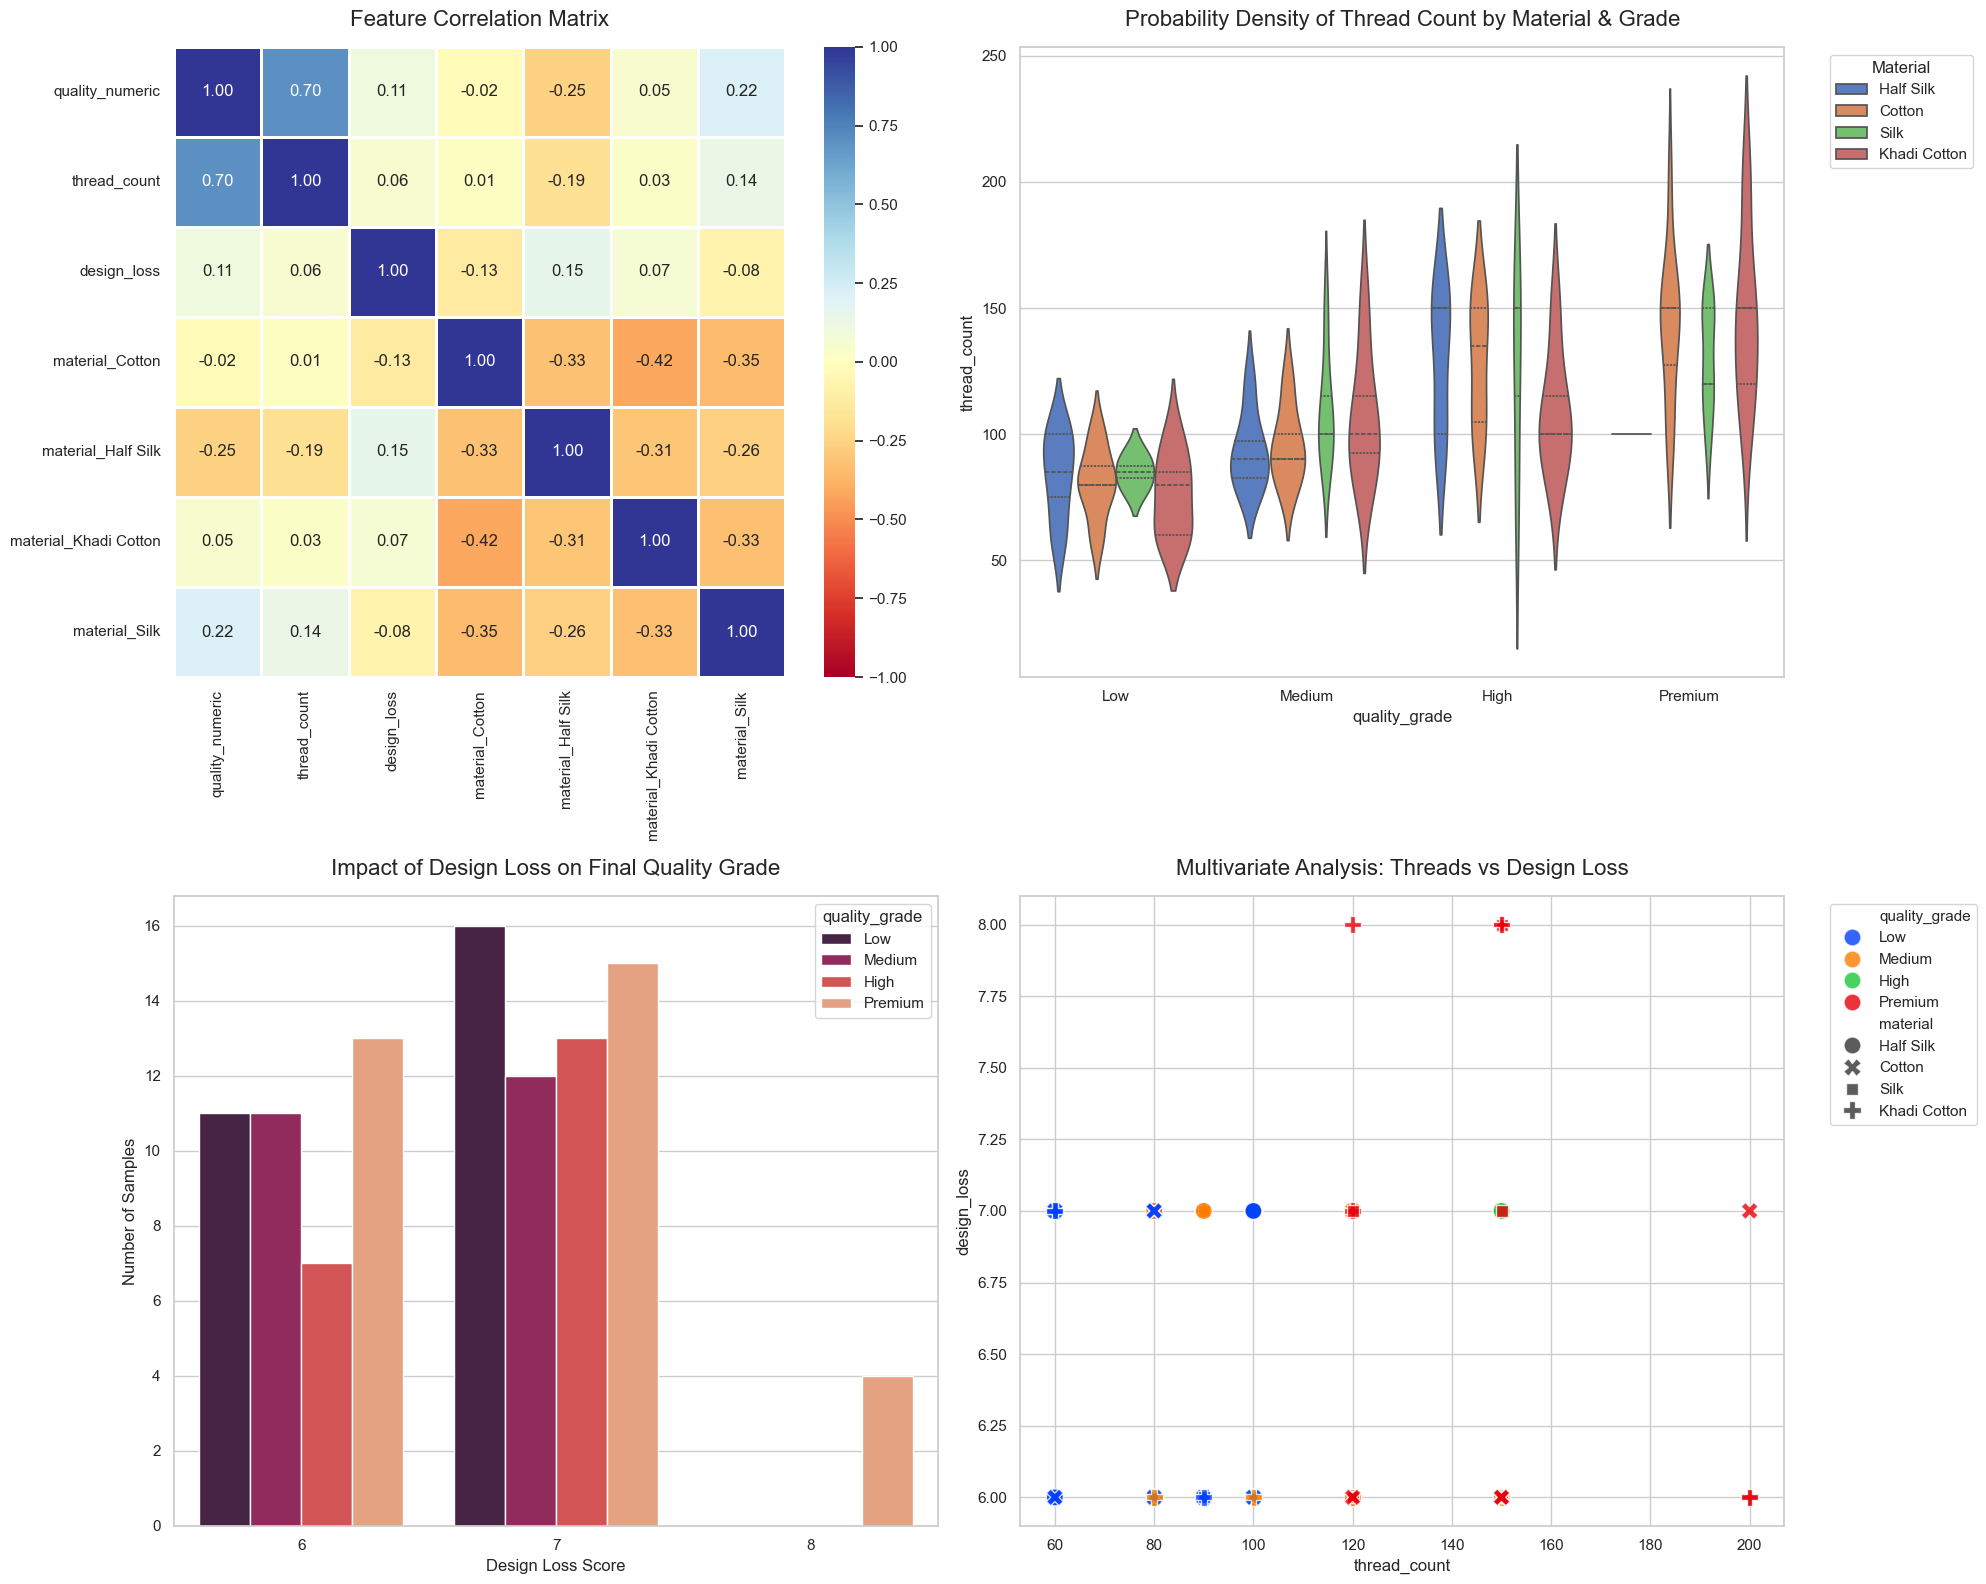

In [32]:

print("--- Advanced Statistical Visualizations for Report ---")

# Create a 2x2 grid for advanced plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Feature Correlation Heatmap
# ---------------------------------------------------------
# We map ordinal quality to numbers so we can calculate mathematical correlation
grade_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Premium': 3}
df_corr = df.copy()
df_corr['quality_numeric'] = df_corr['quality_grade'].map(grade_map)

# One-hot encode the materials to see how specific fabrics correlate
df_corr = pd.get_dummies(df_corr, columns=['material'])
corr_columns = ['quality_numeric', 'thread_count', 'design_loss'] + [c for c in df_corr.columns if 'material_' in c]

# Compute and plot the correlation matrix
corr_matrix = df_corr[corr_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=1, ax=axes[0, 0], vmin=-1, vmax=1)
axes[0, 0].set_title('Feature Correlation Matrix', fontsize=16, pad=15)

# ---------------------------------------------------------
# Plot 2: Violin Plot (Distribution Density)
# ---------------------------------------------------------
# Violin plots are great for academic papers. They show both the boxplot and the exact probability density.
sns.violinplot(data=df, x='quality_grade', y='thread_count', hue='material',
               order=['Low', 'Medium', 'High', 'Premium'],
               inner="quartile", palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('Probability Density of Thread Count by Material & Grade', fontsize=16, pad=15)
axes[0, 1].legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# Plot 3: Impact of Design Loss on Quality
# ---------------------------------------------------------
# Shows if higher design loss forces a saree into a lower grade category
sns.countplot(data=df, x='design_loss', hue='quality_grade',
              hue_order=['Low', 'Medium', 'High', 'Premium'],
              palette='rocket', ax=axes[1, 0])
axes[1, 0].set_title('Impact of Design Loss on Final Quality Grade', fontsize=16, pad=15)
axes[1, 0].set_xlabel('Design Loss Score')
axes[1, 0].set_ylabel('Number of Samples')

# ---------------------------------------------------------
# Plot 4: Multivariate Scatter Plot
# ---------------------------------------------------------
# Combines 4 dimensions of data: X (Thread Count), Y (Design Loss), Color (Grade), Shape (Material)
sns.scatterplot(data=df, x='thread_count', y='design_loss', hue='quality_grade',
                style='material', s=150, alpha=0.8,
                hue_order=['Low', 'Medium', 'High', 'Premium'],
                palette='bright', ax=axes[1, 1])
axes[1, 1].set_title('Multivariate Analysis: Threads vs Design Loss', fontsize=16, pad=15)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [33]:
# 1. Encode Target Labels (Low, Medium, High, Premium -> 0, 1, 2, 3)
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['quality_grade'])

# 2. Encode Categorical Features & Scale Numerical Features
df = pd.get_dummies(df, columns=['material'], drop_first=False)
feature_cols = ['thread_count', 'design_loss'] + [col for col in df.columns if col.startswith('material_')]

scaler = StandardScaler()
df[['thread_count', 'design_loss']] = scaler.fit_transform(df[['thread_count', 'design_loss']])

# 3. Train-Test Split (80% Train, 20% Test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# 4. Define PyTorch Image Transformations
# MobileNetV2 expects images resized to 224x224 and normalized with specific mean/std
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Build Custom PyTorch Dataset
class JamdaniMultimodalDataset(Dataset):
    def __init__(self, dataframe, img_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Image
        img_name = self.dataframe.loc[idx, 'image_name']
        img_path = os.path.join(self.img_folder, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Tabular data
        tabular_data = self.dataframe.loc[idx, feature_cols].values.astype(np.float32)
        tabular_tensor = torch.tensor(tabular_data)

        # Label
        label = self.dataframe.loc[idx, 'target']
        label_tensor = torch.tensor(label, dtype=torch.long)

        return image, tabular_tensor, label_tensor

# 6. Create DataLoaders (Batches the data automatically)
train_dataset = JamdaniMultimodalDataset(train_df, 'Images', transform=image_transforms)
test_dataset = JamdaniMultimodalDataset(test_df, 'Images', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

print(f"Tabular features dimension: {len(feature_cols)}")
feature_cols

Tabular features dimension: 6


['thread_count',
 'design_loss',
 'material_Cotton',
 'material_Half Silk',
 'material_Khadi Cotton',
 'material_Silk']

In [34]:
class MultimodalLateFusion(nn.Module):
    def __init__(self, tabular_dim, num_classes=4):
        super(MultimodalLateFusion, self).__init__()

        # --- Branch 1: Image Feature Extractor ---
        # Load pre-trained MobileNetV2
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.image_features = mobilenet.features

        # Freeze the pre-trained weights
        for param in self.image_features.parameters():
            param.requires_grad = False

        # Reduce MobileNet's 1280 feature maps down to 128
        self.image_pool_and_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # --- Branch 2: Tabular Feature Extractor ---
        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # --- Branch 3: Fusion & Classification Head ---
        # Concatenated size: 128 (image) + 64 (tabular) = 192
        self.fusion_model = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes) # Raw logits (No softmax needed here for PyTorch CrossEntropyLoss)
        )

    def forward(self, image_x, tabular_x):
        # Pass image through CNN
        img_out = self.image_features(image_x)
        img_out = self.image_pool_and_fc(img_out)

        # Pass tabular data through Dense layers
        tab_out = self.tabular_model(tabular_x)

        # Concatenate on the feature dimension (dim=1)
        combined = torch.cat((img_out, tab_out), dim=1)

        # Pass through final fusion layers
        output = self.fusion_model(combined)
        return output

# Instantiate the model and move it to the GPU
tabular_input_dim = len(feature_cols)
model = MultimodalLateFusion(tabular_dim=tabular_input_dim).to(device)
print(tabular_input_dim)

print(model)


6
MultimodalLateFusion(
  (image_features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): Bat

Starting training...
Epoch 1/30 | Train Loss: 1.3765 Acc: 0.3827 | Val Loss: 1.3569 Acc: 0.4762
Epoch 2/30 | Train Loss: 1.3384 Acc: 0.4938 | Val Loss: 1.3162 Acc: 0.5238
Epoch 3/30 | Train Loss: 1.3118 Acc: 0.4568 | Val Loss: 1.2535 Acc: 0.4286
Epoch 4/30 | Train Loss: 1.1678 Acc: 0.5802 | Val Loss: 1.1863 Acc: 0.4286
Epoch 5/30 | Train Loss: 1.0884 Acc: 0.5432 | Val Loss: 1.0544 Acc: 0.4762
Epoch 6/30 | Train Loss: 0.9735 Acc: 0.5432 | Val Loss: 0.9646 Acc: 0.5238
Epoch 7/30 | Train Loss: 0.7386 Acc: 0.7160 | Val Loss: 0.8530 Acc: 0.6667
Epoch 8/30 | Train Loss: 0.8084 Acc: 0.6790 | Val Loss: 0.9599 Acc: 0.5714
Epoch 9/30 | Train Loss: 0.6287 Acc: 0.7778 | Val Loss: 0.7884 Acc: 0.6190
Epoch 10/30 | Train Loss: 0.6292 Acc: 0.7531 | Val Loss: 0.8142 Acc: 0.6190
Epoch 11/30 | Train Loss: 0.6730 Acc: 0.7160 | Val Loss: 0.8409 Acc: 0.6190
Epoch 12/30 | Train Loss: 0.4474 Acc: 0.8025 | Val Loss: 0.8391 Acc: 0.6190
Epoch 13/30 | Train Loss: 0.4821 Acc: 0.8395 | Val Loss: 0.8837 Acc: 0.5238


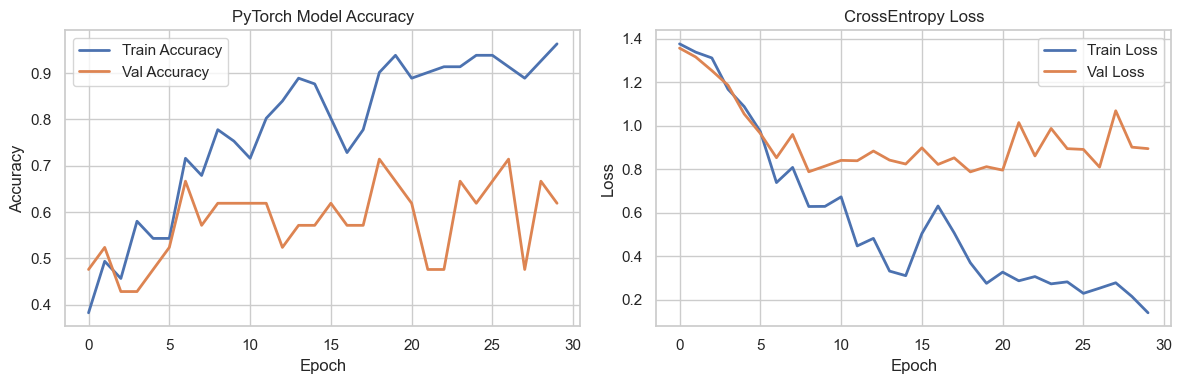

In [35]:
# Hyperparameters
epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking history for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss, running_corrects, total_samples = 0.0, 0, 0

    for images, tabular, labels in train_loader:
        # Move data to GPU
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss, val_corrects, val_samples = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for images, tabular, labels in test_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_samples += images.size(0)

    epoch_val_loss = val_loss / val_samples
    epoch_val_acc = val_corrects / val_samples

    # Save metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Plotting the Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', lw=2)
plt.title('PyTorch Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', lw=2)
plt.plot(history['val_loss'], label='Val Loss', lw=2)
plt.title('CrossEntropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
# Install Optuna silently
!pip install -q optuna
import optuna


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
train_dataset = JamdaniMultimodalDataset(train_df, 'Images', transform=image_transforms)
val_dataset = JamdaniMultimodalDataset(test_df, 'Images', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import optuna


NUM_CLASSES = 4
TABULAR_DIM = len(feature_cols)# <-- Replace with your actual number of tabular columns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define the Multi-Modal Architecture ---
class MultiModalNet(nn.Module):
    def __init__(self, base_image_model, tabular_dim, num_classes, dropout_rate=0.2):
        super(MultiModalNet, self).__init__()

        # Base image extractor (MobileNetV2 features)
        self.image_backbone = base_image_model.features

        # --- Branch 1: Image Pool & FC ---
        # MobileNetV2 outputs 1280 channels
        self.image_pool_and_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate) # Using Optuna's dropout
        )

        # --- Branch 2: Tabular Feature Extractor ---
        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate) # Using Optuna's dropout
        )

        # --- Branch 3: Fusion & Classification Head ---
        self.fusion_model = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Using Optuna's dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, image, tabular):
        img_features = self.image_backbone(image)
        img_out = self.image_pool_and_fc(img_features)
        tab_out = self.tabular_model(tabular)
        fused = torch.cat((img_out, tab_out), dim=1)
        return self.fusion_model(fused)


# --- 2. Initialize Model Function ---
def get_multimodal_model(dropout_rate=0.2):
    """Initializes MobileNetV2 and wraps it in the MultiModalNet."""
    base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Freeze image feature extractor layers for faster hyperparameter search
    for param in base_model.features.parameters():
        param.requires_grad = False

    # Instantiate our custom class
    model = MultiModalNet(
        base_image_model=base_model,
        tabular_dim=TABULAR_DIM,
        num_classes=NUM_CLASSES,
        dropout_rate=dropout_rate
    )
    return model


# --- 3. Optuna Objective Function ---
def objective(trial):
    # Suggest Hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam", "SGD"])

    model = get_multimodal_model(dropout_rate=dropout).to(device)
    modelcheck=model;
    criterion = nn.CrossEntropyLoss()


    # Get only the un-frozen parameters (the newly added linear and fusion layers)
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name == "SGD":
        optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = getattr(optim, optimizer_name)(trainable_params, lr=lr, weight_decay=weight_decay)

    epochs_per_trial = 5
    for epoch in range(epochs_per_trial):
        model.train()

        # --- Training Loop ---
        for batch in train_loader:
            # Safely unpack Image, Tabular, and Labels
            if isinstance(batch, dict):
                images = batch['image']
                tabular = batch['tabular'] # <-- Ensure this matches your dataset keys
                labels = batch['label']
            else:
                # Assumes dataset returns: (image, tabular, label)
                images, tabular, labels = batch[0], batch[1], batch[2]

            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass requires both inputs
            outputs = model(images, tabular)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # --- Validation Loop ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, dict):
                    images = batch['image']
                    tabular = batch['tabular']
                    labels = batch['label']
                else:
                    images, tabular, labels = batch[0], batch[1], batch[2]

                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)

                # Forward pass requires both inputs
                outputs = model(images, tabular)

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_acc

In [39]:
# Create study and run optimization
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=15)

print("\n--- Optuna Study Summary ---")
print(f"Best Validation Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-09-12 13:33:15,811] A new study created in memory with name: no-name-04c8fbf4-dca8-461d-a02f-d1ac1d6b31d8
[I 2026-09-12 13:33:21,300] Trial 0 finished with value: 0.3333333333333333 and parameters: {'lr': 0.007522116713695002, 'dropout': 0.31198949475408766, 'weight_decay': 2.265616345362569e-05, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-09-12 13:33:26,915] Trial 1 finished with value: 0.19047619047619047 and parameters: {'lr': 4.07923936858762e-05, 'dropout': 0.10590493807689678, 'weight_decay': 0.0001210807894488233, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-09-12 13:33:31,584] Trial 2 finished with value: 0.2857142857142857 and parameters: {'lr': 3.171696305257636e-05, 'dropout': 0.2013721226233155, 'weight_decay': 0.0007353935846449995, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.3333333333333333.
[I 2026-09-12 13:33:35,741] Trial 3 finished with value: 0.3333333333333333 and parameters: {'lr':


--- Optuna Study Summary ---
Best Validation Accuracy: 0.5714
Best Hyperparameters:
  lr: 0.007626499862429824
  dropout: 0.3436015505805241
  weight_decay: 5.168617688018712e-06
  optimizer: Adam


In [40]:
import copy
print("\n--- Training Final Model ---")
best_params = study.best_params

#print(best_params["batch_size"])

# Use a default batch size if not tuned by Optuna
batch_size = best_params.get("batch_size", 32)

# If train_dataset exists, rebuild loaders; otherwise use existing loaders
if "train_dataset" in globals() and "val_dataset" in globals():
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

final_model = get_multimodal_model(dropout_rate=best_params["dropout"]).to(device)

# Unfreeze top layers of MobileNet for fine-tuning
# The corrected line
for param in final_model.image_backbone[-3:].parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

if best_params["optimizer"] == "SGD":
    optimizer = optim.SGD(
        final_model.parameters(),
        lr=best_params["lr"],
        momentum=0.9,
        weight_decay=best_params["weight_decay"]
    )
else:
    optimizer = getattr(optim, best_params["optimizer"])(
        final_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

num_epochs = 30
best_accuracy = 0.0
best_model_weights = copy.deepcopy(final_model.state_dict())

for epoch in range(num_epochs):
    final_model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Robust unpacking for multimodal or tuple batches
    for batch in train_loader:
        if isinstance(batch, dict):
            images, tabular, labels = batch['image'], batch['tabular'], batch['label']
        else:
            images, tabular, labels = batch[0], batch[1], batch[2]

        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        optimizer.zero_grad()
        # The corrected line:
        outputs = final_model(images, tabular)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    scheduler.step()
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    final_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, dict):
                images, tabular, labels = batch['image'], batch['tabular'], batch['label']
            else:
                images, tabular, labels = batch[0], batch[1], batch[2]

            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
            # The corrected line:
            outputs = final_model(images, tabular)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_weights = copy.deepcopy(final_model.state_dict())

# Save best model checkpoint
final_model.load_state_dict(best_model_weights)
torch.save(final_model.state_dict(), 'best_mobilenet_jamdani.pth')
print(f"\nFinal Best Validation Accuracy: {best_accuracy:.4f}")
print("Saved model checkpoint as 'best_mobilenet_jamdani.pth' in your Drive!")


--- Training Final Model ---
Epoch 01/30 | Train Loss: 1.3733, Acc: 0.2593 | Val Loss: 1.2545, Acc: 0.3333
Epoch 02/30 | Train Loss: 1.1382, Acc: 0.3704 | Val Loss: 1.1317, Acc: 0.4286
Epoch 03/30 | Train Loss: 0.8712, Acc: 0.6667 | Val Loss: 3.8581, Acc: 0.3810
Epoch 04/30 | Train Loss: 0.5733, Acc: 0.7284 | Val Loss: 18.1419, Acc: 0.3333
Epoch 05/30 | Train Loss: 0.8959, Acc: 0.7531 | Val Loss: 28.8968, Acc: 0.3810
Epoch 06/30 | Train Loss: 0.8298, Acc: 0.8025 | Val Loss: 16.6842, Acc: 0.3810
Epoch 07/30 | Train Loss: 1.1028, Acc: 0.7778 | Val Loss: 7.0162, Acc: 0.5238
Epoch 08/30 | Train Loss: 0.6246, Acc: 0.8519 | Val Loss: 6.2924, Acc: 0.5714
Epoch 09/30 | Train Loss: 0.4578, Acc: 0.8765 | Val Loss: 5.3150, Acc: 0.5238
Epoch 10/30 | Train Loss: 0.2473, Acc: 0.9383 | Val Loss: 3.7780, Acc: 0.5714
Epoch 11/30 | Train Loss: 0.6767, Acc: 0.8642 | Val Loss: 2.6500, Acc: 0.5714
Epoch 12/30 | Train Loss: 0.2089, Acc: 0.9383 | Val Loss: 1.8386, Acc: 0.5714
Epoch 13/30 | Train Loss: 0.556

In [41]:
print("\n--- Optimized Hyperparameters ---")
for key, value in best_params.items():
    print(f"{key}: {value}")


--- Optimized Hyperparameters ---
lr: 0.007626499862429824
dropout: 0.3436015505805241
weight_decay: 5.168617688018712e-06
optimizer: Adam


--- Starting 5-Fold Stratified Cross-Validation ---

>> Fold 1/5 Training...
Fold 1 Best Validation Accuracy: 61.90%
*** Fold 1 saved as BEST fold ***

>> Fold 2/5 Training...
Fold 2 Best Validation Accuracy: 85.71%
*** Fold 2 saved as BEST fold ***

>> Fold 3/5 Training...
Fold 3 Best Validation Accuracy: 70.00%

>> Fold 4/5 Training...
Fold 4 Best Validation Accuracy: 70.00%

>> Fold 5/5 Training...
Fold 5 Best Validation Accuracy: 75.00%

5-Fold CV Final Results:
 - Fold 1: 61.90%
 - Fold 2: 85.71%
 - Fold 3: 70.00%
 - Fold 4: 70.00%
 - Fold 5: 75.00%
Average Accuracy: 72.52% (+/- 7.82%)

Best Fold Information:
Best Fold: 2
Best Fold Accuracy: 85.71%
Best Fold Training Samples: 81
Best Fold Validation Samples: 21


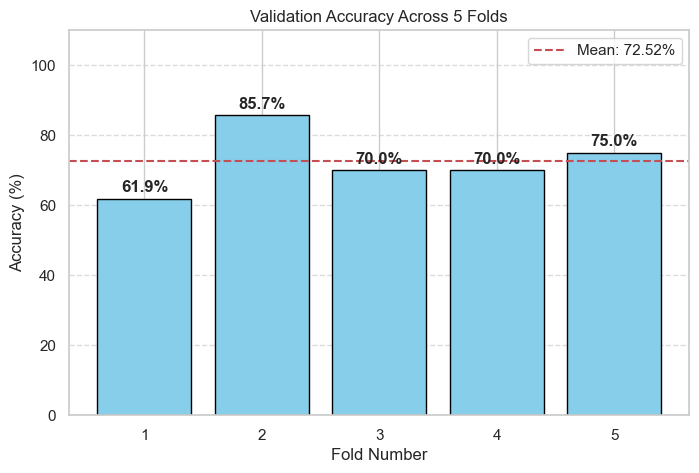

In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

k_folds = 5
epochs_per_fold = 15

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_results = []
all_train_loss = []
all_val_acc = []

# Store the best fold
best_fold_acc = -1
best_fold_number = None
best_train_loader = None
best_val_loader = None
best_train_df = None
best_val_df = None
best_scaler = None

print(f"--- Starting {k_folds}-Fold Stratified Cross-Validation ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['target'])):
    print(f"\n>> Fold {fold + 1}/{k_folds} Training...")

    # Split DataFrame
    train_df = df.iloc[train_idx].copy().reset_index(drop=True)
    val_df = df.iloc[val_idx].copy().reset_index(drop=True)

    # Scale data inside the fold to prevent data leakage
    scaler = StandardScaler()

    train_df[['thread_count', 'design_loss']] = scaler.fit_transform(
        train_df[['thread_count', 'design_loss']]
    )

    val_df[['thread_count', 'design_loss']] = scaler.transform(
        val_df[['thread_count', 'design_loss']]
    )

    # Create datasets
    train_dataset = JamdaniMultimodalDataset(
        train_df, 'Images', transform=image_transforms
    )

    val_dataset = JamdaniMultimodalDataset(
        val_df, 'Images', transform=image_transforms
    )

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=False
    )

    # Fresh model for each fold
    model = MultimodalLateFusion(
        tabular_dim=len(feature_cols)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    fold_train_loss_history = []
    fold_val_acc_history = []

    # Training
    for epoch in range(epochs_per_fold):
        model.train()
        running_loss = 0.0

        for images, tabular, labels in train_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        fold_train_loss_history.append(epoch_train_loss)

        # Validation
        model.eval()
        val_corrects = 0
        val_samples = 0

        with torch.no_grad():
            for images, tabular, labels in val_loader:
                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)

                outputs = model(images, tabular)
                _, preds = torch.max(outputs, 1)

                val_corrects += torch.sum(preds == labels.data).item()
                val_samples += images.size(0)

        epoch_val_acc = val_corrects / val_samples * 100
        fold_val_acc_history.append(epoch_val_acc)

    # Best accuracy of current fold
    current_fold_best_acc = max(fold_val_acc_history)

    fold_results.append(current_fold_best_acc)
    all_train_loss.append(fold_train_loss_history)
    all_val_acc.append(fold_val_acc_history)

    print(
        f"Fold {fold + 1} Best Validation Accuracy: "
        f"{current_fold_best_acc:.2f}%"
    )

    # Save data from the best-performing fold
    if current_fold_best_acc > best_fold_acc:
        best_fold_acc = current_fold_best_acc
        best_fold_number = fold + 1

        best_train_loader = train_loader
        best_val_loader = val_loader

        best_train_df = train_df.copy()
        best_val_df = val_df.copy()

        best_scaler = copy.deepcopy(scaler)

        print(f"*** Fold {fold + 1} saved as BEST fold ***")


# Final results
print("\n=======================================================")
print(f"{k_folds}-Fold CV Final Results:")

for i, acc in enumerate(fold_results):
    print(f" - Fold {i + 1}: {acc:.2f}%")

mean_accuracy = np.mean(fold_results)
std_accuracy = np.std(fold_results)

print(
    f"Average Accuracy: {mean_accuracy:.2f}% "
    f"(+/- {std_accuracy:.2f}%)"
)

print("=======================================================")

# Best fold information
print("\nBest Fold Information:")
print(f"Best Fold: {best_fold_number}")
print(f"Best Fold Accuracy: {best_fold_acc:.2f}%")
print(f"Best Fold Training Samples: {len(best_train_df)}")
print(f"Best Fold Validation Samples: {len(best_val_df)}")

# Plot results
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(1, k_folds + 1),
    fold_results,
    color='skyblue',
    edgecolor='black'
)

plt.axhline(
    y=mean_accuracy,
    color='r',
    linestyle='--',
    label=f'Mean: {mean_accuracy:.2f}%'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Validation Accuracy Across 5 Folds')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Starting training...
Epoch 1/30 | Train Loss: 0.4917 Acc: 0.8025 | Val Loss: 0.3158 Acc: 0.9524
Epoch 2/30 | Train Loss: 0.4344 Acc: 0.8395 | Val Loss: 0.2663 Acc: 0.9524
Epoch 3/30 | Train Loss: 0.5647 Acc: 0.7654 | Val Loss: 0.2590 Acc: 0.9524
Epoch 4/30 | Train Loss: 0.3618 Acc: 0.8395 | Val Loss: 0.2385 Acc: 0.9524
Epoch 5/30 | Train Loss: 0.3668 Acc: 0.8272 | Val Loss: 0.2666 Acc: 0.9524
Epoch 6/30 | Train Loss: 0.4068 Acc: 0.8519 | Val Loss: 0.3951 Acc: 0.9048
Epoch 7/30 | Train Loss: 0.3927 Acc: 0.9136 | Val Loss: 0.4208 Acc: 0.9048
Epoch 8/30 | Train Loss: 0.3192 Acc: 0.8642 | Val Loss: 0.2576 Acc: 0.9524
Epoch 9/30 | Train Loss: 0.4748 Acc: 0.7901 | Val Loss: 0.2038 Acc: 0.9524
Epoch 10/30 | Train Loss: 0.3464 Acc: 0.8519 | Val Loss: 0.3628 Acc: 0.8571
Epoch 11/30 | Train Loss: 0.4164 Acc: 0.8395 | Val Loss: 0.4177 Acc: 0.8095
Epoch 12/30 | Train Loss: 0.2886 Acc: 0.9259 | Val Loss: 0.2954 Acc: 0.9048
Epoch 13/30 | Train Loss: 0.2348 Acc: 0.9383 | Val Loss: 0.2966 Acc: 0.9048


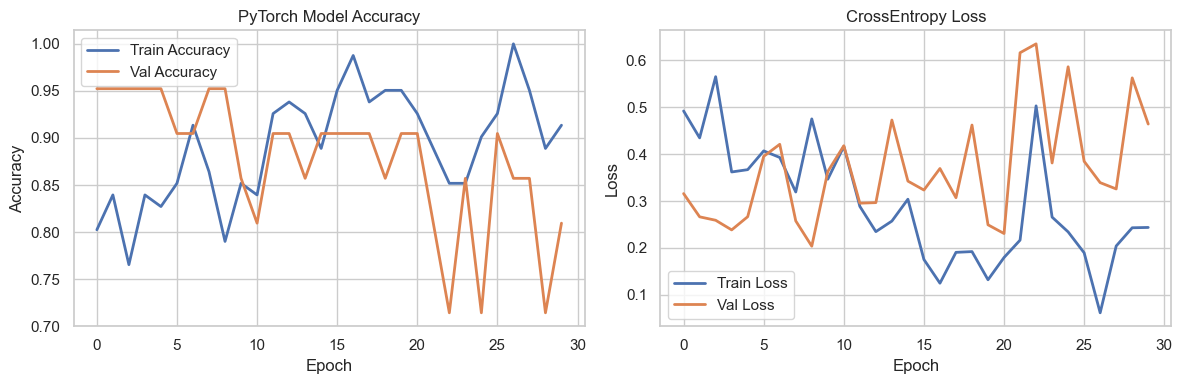

In [43]:
# Hyperparameters
epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking history for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss, running_corrects, total_samples = 0.0, 0, 0

    for images, tabular, labels in best_train_loader:
        # Move data to GPU
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss, val_corrects, val_samples = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for images, tabular, labels in best_val_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_samples += images.size(0)

    epoch_val_loss = val_loss / val_samples
    epoch_val_acc = val_corrects / val_samples

    # Save metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Plotting the Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', lw=2)
plt.title('PyTorch Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', lw=2)
plt.plot(history['val_loss'], label='Val Loss', lw=2)
plt.title('CrossEntropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()